# **Customer Churn Predictor**

## Data Formation

### Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn.csv to customer_churn.csv


### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [4]:
df = pd.read_csv("customer_churn.csv")
df.head()

,CustomerID,Age,MonthlyCharges,Tenure,SupportCalls,ContractType,InternetService,PaymentMethod,Churn_Probability,Churn
0,C00001,56,72.97,22,1,Month-to-Month,DSL,Credit Card,0.201,0
1,C00002,69,101.51,68,2,Month-to-Month,Fiber,Credit Card,0.575,1
2,C00003,46,69.81,69,1,Month-to-Month,DSL,Credit Card,0.285,0
3,C00004,32,26.72,37,4,One Year,Fiber,Electronic Check,0.284,0
4,C00005,60,60.52,49,3,Month-to-Month,DSL,Bank Transfer,0.331,0


### Data Preparation

In [5]:
df = df.drop("CustomerID", axis=1)
y = df["Churn_Probability"]   # Continuous 0–1
X = df.drop("Churn_Probability", axis=1)

In [6]:
X = pd.get_dummies(X, drop_first=True)

## Train - Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Train Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_lr_train_pred = lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)

## Train Random Forest Regressorion

In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

## Evaluate Linear Regression and Radom Forest Regression

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)

print("\n🔹 Linear Regression")

lr_train_r2 = r2_score(y_train, y_lr_train_pred)
lr_test_r2 = r2_score(y_test, y_lr_test_pred)
lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_test_rmse = np.sqrt(lr_test_mse)

print(f"Train R2  : {lr_train_r2:.4f}")
print(f"Test R2   : {lr_test_r2:.4f}")
print(f"Test MSE  : {lr_test_mse:.6f}")
print(f"Test RMSE : {lr_test_rmse:.6f}")


print("\n🔹 Random Forest Regressor")

rf_train_r2 = r2_score(y_train, y_rf_train_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)
rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_test_rmse = np.sqrt(rf_test_mse)

print(f"Train R2  : {rf_train_r2:.4f}")
print(f"Test R2   : {rf_test_r2:.4f}")
print(f"Test MSE  : {rf_test_mse:.6f}")
print(f"Test RMSE : {rf_test_rmse:.6f}")

print("\n" + "="*50)

MODEL PERFORMANCE COMPARISON

🔹 Linear Regression
Train R2  : 0.8118
Test R2   : 0.8303
Test MSE  : 0.007652
Test RMSE : 0.087477

🔹 Random Forest Regressor
Train R2  : 0.9897
Test R2   : 0.9367
Test MSE  : 0.002856
Test RMSE : 0.053438



## **Visualization**

### DIAGONAL CLOUD GRAPH

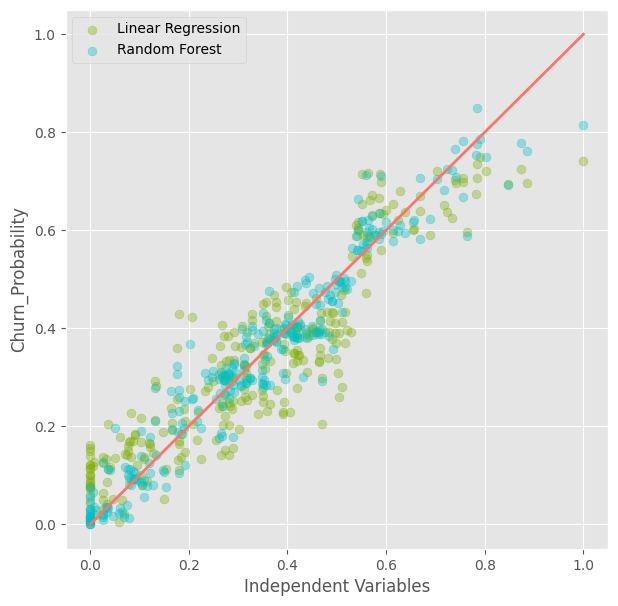

In [17]:
plt.style.use('ggplot')
plt.figure(figsize=(7,7))

# Linear Regression
plt.scatter(y_test, y_lr_test_pred,
            color='#7CAE00',
            alpha=0.35,
            s=40,
            label='Linear Regression')

# Random Forest
plt.scatter(y_test, y_rf_test_pred,
            color='#00BFC4',
            alpha=0.35,
            s=40,
            label='Random Forest')

plt.plot([0,1],[0,1],'#F8766D', linewidth=2)

plt.ylabel('Churn_Probability')
plt.xlabel('Independent Variables')
plt.legend()

plt.show()

### Residual Plot

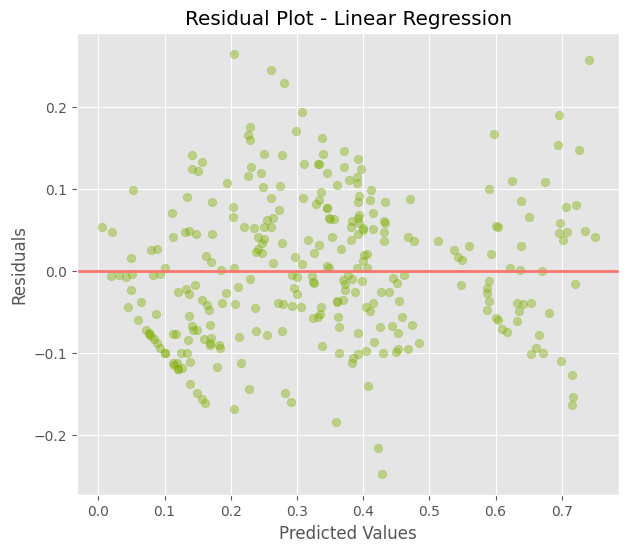

In [18]:
residuals = y_test - y_lr_test_pred

plt.figure(figsize=(7,6))
plt.scatter(y_lr_test_pred, residuals,
            color='#7CAE00',
            alpha=0.4)

plt.axhline(y=0, color='#F8766D', linewidth=2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

###Feature Importance - Random Forest

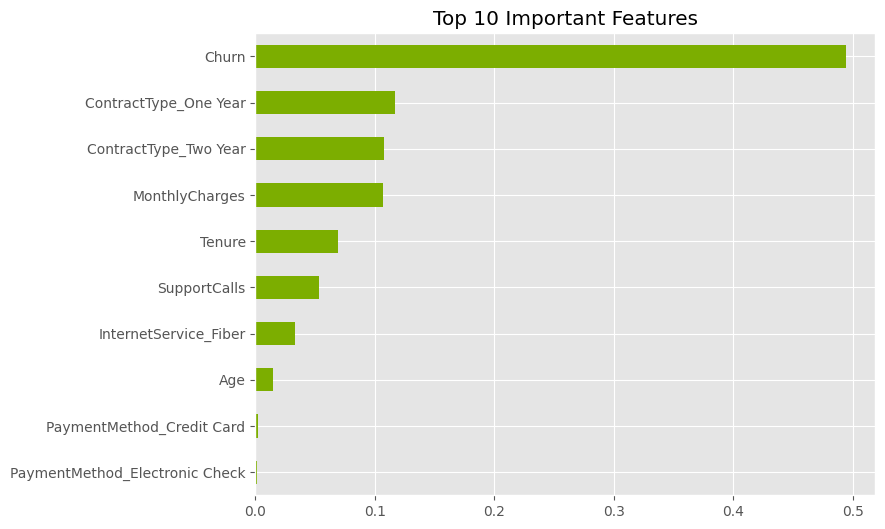

In [19]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh', color='#7CAE00')
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()